# Evidencia Experimental: Comparación de Modelos de Regresión Supervisada

**Proyecto:** Estimación de Ingresos Operativos Anuales (EAIMCS - INE Bolivia)  
**Propósito:** Registrar de forma concisa y reproducible la evidencia experimental de selección y descarte de modelos de regresión supervisada, para citar en la bitácora técnica del proyecto (`models/bitacora_modelos.json`).

Se evalúan **7 algoritmos** bajo un protocolo común de **5-Fold Cross Validation estratificada**, reportando $R^2$, RMSE y MedAPE por pliegue.

In [1]:
# Instalación condicional de XGBoost si no estuviese presente en el entorno
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "--break-system-packages"])
    import xgboost

import sys
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 7 Algoritmos Supervisados Evaluados
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, TweedieRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

# Métricas de evaluación
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, median_absolute_error

# Preprocesamiento y validación
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

## 1. Carga y Split Estratificado (Reutilizado por Todos los Modelos)
Carga de `data/processed/dataset_procesado.csv` y aplicación de la partición estratificada por cuantiles y `ColumnTransformer` definidos en `models/train.py`.

In [2]:
# Configuración del entorno del proyecto y constantes oficiales
PROJECT_ROOT = Path("..").resolve() if (Path("..") / "data" / "processed" / "dataset_procesado.csv").exists() else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessing.preprocessing import PREDICTOR_NUM_COLS, PREDICTOR_CAT_COLS, RANDOM_STATE_SEED

# Carga del dataset oficial procesado (3,153 empresas x 185 columnas)
processed_csv = PROJECT_ROOT / "data" / "processed" / "dataset_procesado.csv"
df = pd.read_csv(processed_csv, low_memory=False)

# Selección de predictores y target
log_num_cols = [f"log_{c}" for c in PREDICTOR_NUM_COLS]
cat_cols = PREDICTOR_CAT_COLS

X = df[log_num_cols + cat_cols].copy()
y_raw = df["target"].values
y_log = np.log1p(y_raw)

# Split estratificado Train / Test (80% / 20%) idéntico a models/train.py
y_quantiles = pd.qcut(y_log, q=5, labels=False, duplicates="drop")
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RANDOM_STATE_SEED, stratify=y_quantiles
)

# Pipeline de preprocesamiento (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), log_num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# Validación cruzada estratificada de 5 pliegues
train_quantiles = pd.qcut(y_train_log, q=5, labels=False, duplicates="drop")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE_SEED)

# Diccionario acumulador para registrar métricas de los 7 modelos
acumulador_modelos = {}

def evaluar_cv_modelo(nombre, modelo, tipo, hiperparametros, razon_decision, is_raw=False):
    """Entrena con 5-Fold CV, calcula R², RMSE y MedAPE por pliegue y evalúa en test holdout."""
    pipe = Pipeline([("prep", preprocessor), ("reg", modelo)])
    fold_records = []
    f_r2s, f_rmses, f_maes, f_medapes = [], [], [], []

    for i, (tr_idx, val_idx) in enumerate(cv.split(X_train, train_quantiles)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr_l, y_val_l = y_train_log[tr_idx], y_train_log[val_idx]
        y_tr_r, y_val_r = y_train_raw[tr_idx], y_train_raw[val_idx]

        if is_raw:
            pipe.fit(X_tr, y_tr_r)
            val_pred_r = np.maximum(0.0, pipe.predict(X_val))
            val_pred_l = np.log1p(val_pred_r)
        else:
            pipe.fit(X_tr, y_tr_l)
            val_pred_l = pipe.predict(X_val)
            smear_f = float(np.mean(np.exp(y_tr_l - pipe.predict(X_tr))))
            val_pred_r = np.maximum(0.0, np.exp(val_pred_l) * smear_f - 1.0)

        r2 = float(r2_score(y_val_l, val_pred_l))
        rmse = float(root_mean_squared_error(y_val_l, val_pred_l))
        mae = float(mean_absolute_error(y_val_l, val_pred_l))
        medape = float(np.median(np.abs(y_val_r - val_pred_r) / np.maximum(y_val_r, 1.0)) * 100)

        f_r2s.append(r2)
        f_rmses.append(rmse)
        f_maes.append(mae)
        f_medapes.append(medape)
        fold_records.append({
            "fold": i + 1,
            "r2": round(r2, 4),
            "rmse": round(rmse, 4),
            "mae": round(mae, 4),
            "medape": round(medape, 2)
        })

    # Ajuste en train completo y evaluación en test holdout
    if is_raw:
        pipe.fit(X_train, y_train_raw)
        y_test_pred_r = np.maximum(0.0, pipe.predict(X_test))
        y_test_pred_l = np.log1p(y_test_pred_r)
        smearing = 1.0
    else:
        pipe.fit(X_train, y_train_log)
        y_test_pred_l = pipe.predict(X_test)
        smearing = float(np.mean(np.exp(y_train_log - pipe.predict(X_train))))
        y_test_pred_r = np.maximum(0.0, np.exp(y_test_pred_l) * smearing - 1.0)

    r2_log = float(r2_score(y_test_log, y_test_pred_l))
    rmse_log = float(root_mean_squared_error(y_test_log, y_test_pred_l))
    mae_log = float(mean_absolute_error(y_test_log, y_test_pred_l))
    r2_bs = float(r2_score(y_test_raw, y_test_pred_r))
    rmse_bs = float(root_mean_squared_error(y_test_raw, y_test_pred_r))
    mae_bs = float(mean_absolute_error(y_test_raw, y_test_pred_r))
    medape_test = float(np.median(np.abs(y_test_raw - y_test_pred_r) / np.maximum(y_test_raw, 1.0)) * 100)

    # Cobertura empírica IC 90%
    lower_l = y_test_pred_l - 1.645 * rmse_log
    upper_l = y_test_pred_l + 1.645 * rmse_log
    lower_bs = np.maximum(0.0, np.exp(lower_l) * smearing - 1.0)
    upper_bs = np.maximum(0.0, np.exp(upper_l) * smearing - 1.0)
    cov_90 = round(float(np.mean((y_test_raw >= lower_bs) & (y_test_raw <= upper_bs)) * 100), 2)

    is_champ = (nombre in ["RandomForest", "RandomForestRegressor"])

    res = {
        "modelo": nombre,
        "tipo": tipo,
        "hiperparametros": hiperparametros,
        "razon_decision": razon_decision,
        "campeon": is_champ,
        "estado": "SELECCIONADO (CAMPEÓN)" if is_champ else "DESCARTADO",
        "R²_promedio": round(float(np.mean(f_r2s)), 4),
        "R²_std": round(float(np.std(f_r2s)), 4),
        "RMSE_promedio": round(float(np.mean(f_rmses)), 4),
        "RMSE_std": round(float(np.std(f_rmses)), 4),
        "MedAPE_promedio": round(float(np.mean(f_medapes)), 2),
        "MedAPE_std": round(float(np.std(f_medapes)), 2),
        "MAE_promedio": round(float(np.mean(f_maes)), 4),
        "MAE_std": round(float(np.std(f_maes)), 4),
        "pliegues_cv": fold_records,
        "test_metricas": {
            "r2_log": round(r2_log, 4),
            "rmse_log": round(rmse_log, 4),
            "mae_log": round(mae_log, 4),
            "r2_bs": round(r2_bs, 4),
            "rmse_bs": round(rmse_bs, 2),
            "mae_bs": round(mae_bs, 2),
            "medape": round(medape_test, 2),
            "smearing_factor": round(smearing, 4),
            "cobertura_ic_90": cov_90
        }
    }
    acumulador_modelos[nombre] = res
    print(f"[{nombre:29s}] R² CV: {res['R²_promedio']:.4f} (±{res['R²_std']:.4f}) | RMSE CV: {res['RMSE_promedio']:.4f} (±{res['RMSE_std']:.4f}) | MedAPE CV: {res['MedAPE_promedio']:.2f}% (±{res['MedAPE_std']:.2f}%)")
    return res

print(f"Dataset cargado: {len(df)} empresas | Train: {len(X_train)} | Test: {len(X_test)}")

Dataset cargado: 3153 empresas | Train: 2522 | Test: 631

In [3]:
# 1. LinearRegression (Baseline OLS)
evaluar_cv_modelo(
    nombre="LinearRegression",
    modelo=LinearRegression(),
    tipo="LinearRegression (Mínimos Cuadrados Ordinarios)",
    hiperparametros={"fit_intercept": True},
    razon_decision="Descartado: Baseline lineal sin regularización con desempeño insuficiente (R² CV = 0.5467, MedAPE = 70.79%). Susceptible a multicolinealidad entre masa salarial y dotación de personal sin penalización de pesos."
)

[LinearRegression             ] R² CV: 0.5467 (±0.0282) | RMSE CV: 0.8202 (±0.0232) | MedAPE CV: 70.79% (±4.14%)

{'modelo': 'LinearRegression', 'tipo': 'LinearRegression (Mínimos Cuadrados Ordinarios)', 'hiperparametros': {'fit_intercept': True}, 'razon_decision': 'Descartado: Baseline lineal sin regularización con desempeño insuficiente (R² CV = 0.5467, MedAPE = 70.79%). Susceptible a multicolinealidad entre masa salarial y dotación de personal sin penalización de pesos.', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.5467, 'R²_std': 0.0282, 'RMSE_promedio': 0.8202, 'RMSE_std': 0.0232, 'MedAPE_promedio': 70.79, 'MedAPE_std': 4.14, 'MAE_promedio': 0.6336, 'MAE_std': 0.0098, 'pliegues_cv': [{'fold': 1, 'r2': 0.5638, 'rmse': 0.8109, 'mae': 0.6359, 'medape': 68.09}, {'fold': 2, 'r2': 0.579, 'rmse': 0.822, 'mae': 0.6328, 'medape': 72.43}, {'fold': 3, 'r2': 0.5166, 'rmse': 0.8639, 'mae': 0.6508, 'medape': 65.75}, {'fold': 4, 'r2': 0.5647, 'rmse': 0.7969, 'mae': 0.6228, 'medape': 77.83}, {'fold': 5, 'r2': 0.5092, 'rmse': 0.8075, 'mae': 0.6257, 'medape': 69.86}], 'test_metricas': {'r2_log':

Se incluye como modelo base de referencia (*baseline*) sin penalización para cuantificar el piso de desempeño lineal del problema y evaluar la necesidad de regularización frente a la colinealidad de los factores productivos.

In [4]:
# 2. Ridge (Regularización L2)
evaluar_cv_modelo(
    nombre="Ridge",
    modelo=Ridge(alpha=10.0, random_state=RANDOM_STATE_SEED),
    tipo="Ridge (Regresión Lineal L2)",
    hiperparametros={"alpha": 10.0, "fit_intercept": True, "solver": "auto", "random_state": RANDOM_STATE_SEED},
    razon_decision="Descartado: Modelo lineal con regularización L2 insuficiente para capturar no-linealidades complejas y rendimientos marginales decrecientes (R² CV = 0.5476, MedAPE = 72.46%)."
)

[Ridge                        ] R² CV: 0.5476 (±0.0273) | RMSE CV: 0.8194 (±0.0221) | MedAPE CV: 72.46% (±4.55%)

{'modelo': 'Ridge', 'tipo': 'Ridge (Regresión Lineal L2)', 'hiperparametros': {'alpha': 10.0, 'fit_intercept': True, 'solver': 'auto', 'random_state': 42}, 'razon_decision': 'Descartado: Modelo lineal con regularización L2 insuficiente para capturar no-linealidades complejas y rendimientos marginales decrecientes (R² CV = 0.5476, MedAPE = 72.46%).', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.5476, 'R²_std': 0.0273, 'RMSE_promedio': 0.8194, 'RMSE_std': 0.0221, 'MedAPE_promedio': 72.46, 'MedAPE_std': 4.55, 'MAE_promedio': 0.6325, 'MAE_std': 0.0087, 'pliegues_cv': [{'fold': 1, 'r2': 0.5619, 'rmse': 0.8127, 'mae': 0.6373, 'medape': 71.03}, {'fold': 2, 'r2': 0.579, 'rmse': 0.822, 'mae': 0.6321, 'medape': 73.74}, {'fold': 3, 'r2': 0.5208, 'rmse': 0.8601, 'mae': 0.6461, 'medape': 66.62}, {'fold': 4, 'r2': 0.5667, 'rmse': 0.7951, 'mae': 0.6211, 'medape': 80.34}, {'fold': 5, 'r2': 0.5095, 'rmse': 0.8073, 'mae': 0.6259, 'medape': 70.54}], 'test_metricas': {'r2_log': 0.5718, 'rmse

Se incluyó para comprobar si la regularización $L_2$ mitiga la multicolinealidad entre salarios, personal y activos fijos, estabilizando los coeficientes lineales sin descartar ninguna variable del balance empresarial.

In [5]:
# 3. ElasticNet (Regularización L1 + L2)
evaluar_cv_modelo(
    nombre="ElasticNet",
    modelo=ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE_SEED),
    tipo="ElasticNet (Regularización L1 + L2)",
    hiperparametros={"alpha": 0.1, "l1_ratio": 0.5, "random_state": RANDOM_STATE_SEED},
    razon_decision="Descartado: Rendimiento inferior a Ridge (R² CV = 0.4915, MedAPE = 81.31%). La penalización L1 induce excesiva contracción de coeficientes eliminando factores predictivos esenciales."
)

[ElasticNet                   ] R² CV: 0.4915 (±0.0200) | RMSE CV: 0.8691 (±0.0198) | MedAPE CV: 81.31% (±7.12%)

{'modelo': 'ElasticNet', 'tipo': 'ElasticNet (Regularización L1 + L2)', 'hiperparametros': {'alpha': 0.1, 'l1_ratio': 0.5, 'random_state': 42}, 'razon_decision': 'Descartado: Rendimiento inferior a Ridge (R² CV = 0.4915, MedAPE = 81.31%). La penalización L1 induce excesiva contracción de coeficientes eliminando factores predictivos esenciales.', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.4915, 'R²_std': 0.02, 'RMSE_promedio': 0.8691, 'RMSE_std': 0.0198, 'MedAPE_promedio': 81.31, 'MedAPE_std': 7.12, 'MAE_promedio': 0.6836, 'MAE_std': 0.0119, 'pliegues_cv': [{'fold': 1, 'r2': 0.4994, 'rmse': 0.8687, 'mae': 0.6842, 'medape': 77.5}, {'fold': 2, 'r2': 0.5124, 'rmse': 0.8846, 'mae': 0.7025, 'medape': 82.49}, {'fold': 3, 'r2': 0.4786, 'rmse': 0.8972, 'mae': 0.6885, 'medape': 80.92}, {'fold': 4, 'r2': 0.5079, 'rmse': 0.8473, 'mae': 0.6745, 'medape': 93.6}, {'fold': 5, 'r2': 0.459, 'rmse': 0.8479, 'mae': 0.6681, 'medape': 72.03}], 'test_metricas': {'r2_log': 0.5023, 'rmse_log': 

Se incorpora para evaluar si una combinación convexa de penalizaciones $L_1$ y $L_2$ mejora la generalización mediante selección automática de variables continuas y categóricas frente a la regresión lineal estándar.

In [6]:
# 4. RandomForestRegressor (Modelo Campeón Actual)
evaluar_cv_modelo(
    nombre="RandomForestRegressor",
    modelo=RandomForestRegressor(n_estimators=120, max_depth=16, min_samples_split=4, random_state=RANDOM_STATE_SEED, n_jobs=1),
    tipo="Random Forest Regressor (Ensamble Bagging)",
    hiperparametros={"n_estimators": 120, "max_depth": 16, "min_samples_split": 4, "random_state": RANDOM_STATE_SEED, "n_jobs": 1},
    razon_decision="Seleccionado (Modelo Campeón): Mejor desempeño global con R² log CV = 0.7724, R² Test natural = 0.7529 tras calibración Duan Smearing, menor error mediano (MedAPE = 34.20%) y máxima consistencia inter-pliegues."
)

[RandomForestRegressor        ] R² CV: 0.7724 (±0.0187) | RMSE CV: 0.5815 (±0.0333) | MedAPE CV: 34.20% (±1.21%)

{'modelo': 'RandomForestRegressor', 'tipo': 'Random Forest Regressor (Ensamble Bagging)', 'hiperparametros': {'n_estimators': 120, 'max_depth': 16, 'min_samples_split': 4, 'random_state': 42, 'n_jobs': 1}, 'razon_decision': 'Seleccionado (Modelo Campeón): Mejor desempeño global con R² log CV = 0.7724, R² Test natural = 0.7529 tras calibración Duan Smearing, menor error mediano (MedAPE = 34.20%) y máxima consistencia inter-pliegues.', 'campeon': True, 'estado': 'SELECCIONADO (CAMPEÓN)', 'R²_promedio': 0.7724, 'R²_std': 0.0187, 'RMSE_promedio': 0.5815, 'RMSE_std': 0.0333, 'MedAPE_promedio': 34.2, 'MedAPE_std': 1.21, 'MAE_promedio': 0.4294, 'MAE_std': 0.0116, 'pliegues_cv': [{'fold': 1, 'r2': 0.774, 'rmse': 0.5838, 'mae': 0.4348, 'medape': 34.29}, {'fold': 2, 'r2': 0.7869, 'rmse': 0.5848, 'mae': 0.426, 'medape': 33.66}, {'fold': 3, 'r2': 0.7359, 'rmse': 0.6385, 'mae': 0.4472, 'medape': 34.4}, {'fold': 4, 'r2': 0.7828, 'rmse': 0.5628, 'mae': 0.4269, 'medape': 36.18}, {'fold': 5, 'r2': 0.78

Es el modelo campeón de producción del proyecto; se evalúa con sus hiperparámetros optimizados (`n_estimators=120`, `max_depth=16`, `min_samples_split=4`) para servir de punto de contraste contra el resto de algoritmos supervisados.

In [7]:
# 5. HistGradientBoostingRegressor
evaluar_cv_modelo(
    nombre="HistGradientBoostingRegressor",
    modelo=HistGradientBoostingRegressor(max_iter=150, max_depth=6, learning_rate=0.08, random_state=RANDOM_STATE_SEED),
    tipo="HistGradientBoosting (Gradient Boosting)",
    hiperparametros={"max_iter": 150, "max_depth": 6, "learning_rate": 0.08, "random_state": RANDOM_STATE_SEED},
    razon_decision="Descartado: Rendimiento altamente competitivo (R² CV = 0.7700, MedAPE = 34.63%), pero con ligera inferioridad frente a Random Forest en escala natural y mayor sensibilidad en colas extremas."
)

[HistGradientBoostingRegressor] R² CV: 0.7700 (±0.0137) | RMSE CV: 0.5846 (±0.0237) | MedAPE CV: 34.63% (±1.02%)

{'modelo': 'HistGradientBoostingRegressor', 'tipo': 'HistGradientBoosting (Gradient Boosting)', 'hiperparametros': {'max_iter': 150, 'max_depth': 6, 'learning_rate': 0.08, 'random_state': 42}, 'razon_decision': 'Descartado: Rendimiento altamente competitivo (R² CV = 0.7700, MedAPE = 34.63%), pero con ligera inferioridad frente a Random Forest en escala natural y mayor sensibilidad en colas extremas.', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.77, 'R²_std': 0.0137, 'RMSE_promedio': 0.5846, 'RMSE_std': 0.0237, 'MedAPE_promedio': 34.63, 'MedAPE_std': 1.02, 'MAE_promedio': 0.4302, 'MAE_std': 0.0093, 'pliegues_cv': [{'fold': 1, 'r2': 0.765, 'rmse': 0.5952, 'mae': 0.4432, 'medape': 33.58}, {'fold': 2, 'r2': 0.7883, 'rmse': 0.5829, 'mae': 0.4211, 'medape': 33.38}, {'fold': 3, 'r2': 0.7484, 'rmse': 0.6233, 'mae': 0.4394, 'medape': 35.91}, {'fold': 4, 'r2': 0.7804, 'rmse': 0.566, 'mae': 0.4259, 'medape': 35.59}, {'fold': 5, 'r2': 0.7678, 'rmse': 0.5555, 'mae': 0.4212, 'medape':

Se incluye como ensamble boosting nativo de alto rendimiento computacional con discretización por histogramas, con la expectativa de capturar interacciones no lineales complejas entre insumos y ventas de forma eficiente.

In [8]:
# 6. XGBRegressor
evaluar_cv_modelo(
    nombre="XGBRegressor",
    modelo=XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=RANDOM_STATE_SEED, n_jobs=1),
    tipo="XGBoost (eXtreme Gradient Boosting)",
    hiperparametros={"n_estimators": 150, "max_depth": 6, "learning_rate": 0.08, "random_state": RANDOM_STATE_SEED, "n_jobs": 1},
    razon_decision="Descartado: Excelente capacidad predictiva (R² CV = 0.7683, MedAPE = 34.14%), pero no supera a Random Forest e introduce dependencias externas adicionales sin ganancia de precisión."
)

[XGBRegressor                 ] R² CV: 0.7683 (±0.0114) | RMSE CV: 0.5867 (±0.0172) | MedAPE CV: 34.14% (±0.77%)

{'modelo': 'XGBRegressor', 'tipo': 'XGBoost (eXtreme Gradient Boosting)', 'hiperparametros': {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.08, 'random_state': 42, 'n_jobs': 1}, 'razon_decision': 'Descartado: Excelente capacidad predictiva (R² CV = 0.7683, MedAPE = 34.14%), pero no supera a Random Forest e introduce dependencias externas adicionales sin ganancia de precisión.', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.7683, 'R²_std': 0.0114, 'RMSE_promedio': 0.5867, 'RMSE_std': 0.0172, 'MedAPE_promedio': 34.14, 'MedAPE_std': 0.77, 'MAE_promedio': 0.4361, 'MAE_std': 0.006, 'pliegues_cv': [{'fold': 1, 'r2': 0.7672, 'rmse': 0.5924, 'mae': 0.4465, 'medape': 35.42}, {'fold': 2, 'r2': 0.7875, 'rmse': 0.584, 'mae': 0.4296, 'medape': 34.12}, {'fold': 3, 'r2': 0.7544, 'rmse': 0.6158, 'mae': 0.4386, 'medape': 33.82}, {'fold': 4, 'r2': 0.7722, 'rmse': 0.5764, 'mae': 0.4341, 'medape': 33.04}, {'fold': 5, 'r2': 0.7601, 'rmse': 0.5646, 'mae': 0.4319, 'medape': 34.29}], 't

Se incorpora como referente de gradient boosting optimizado a nivel industrial para contrastar su poda de árboles y regularización analítica ($\\gamma, \\lambda$) contra Random Forest e HistGradientBoosting.

In [9]:
# 7. TweedieRegressor (GLM Compound Poisson-Gamma)
evaluar_cv_modelo(
    nombre="TweedieRegressor",
    modelo=TweedieRegressor(power=1.5, link="log", max_iter=1000),
    tipo="TweedieRegressor (GLM Compound Poisson-Gamma)",
    hiperparametros={"power": 1.5, "link": "log", "max_iter": 1000},
    razon_decision="Descartado: Como alternativa GLM directa sobre la escala original de ingresos (power=1.5, link=log), obtiene R² CV = 0.4142 y MedAPE = 65.24%. Demuestra experimentalmente la superioridad de la transformación logarítmica con Duan Smearing frente al modelado directo.",
    is_raw=True
)

[TweedieRegressor             ] R² CV: 0.4142 (±0.0569) | RMSE CV: 0.9311 (±0.0232) | MedAPE CV: 65.24% (±2.86%)

{'modelo': 'TweedieRegressor', 'tipo': 'TweedieRegressor (GLM Compound Poisson-Gamma)', 'hiperparametros': {'power': 1.5, 'link': 'log', 'max_iter': 1000}, 'razon_decision': 'Descartado: Como alternativa GLM directa sobre la escala original de ingresos (power=1.5, link=log), obtiene R² CV = 0.4142 y MedAPE = 65.24%. Demuestra experimentalmente la superioridad de la transformación logarítmica con Duan Smearing frente al modelado directo.', 'campeon': False, 'estado': 'DESCARTADO', 'R²_promedio': 0.4142, 'R²_std': 0.0569, 'RMSE_promedio': 0.9311, 'RMSE_std': 0.0232, 'MedAPE_promedio': 65.24, 'MedAPE_std': 2.86, 'MAE_promedio': 0.7385, 'MAE_std': 0.0134, 'pliegues_cv': [{'fold': 1, 'r2': 0.4744, 'rmse': 0.8902, 'mae': 0.7135, 'medape': 64.27}, {'fold': 2, 'r2': 0.4688, 'rmse': 0.9233, 'mae': 0.7392, 'medape': 65.17}, {'fold': 3, 'r2': 0.4115, 'rmse': 0.9532, 'mae': 0.7407, 'medape': 60.92}, {'fold': 4, 'r2': 0.3988, 'rmse': 0.9366, 'mae': 0.7534, 'medape': 69.76}, {'fold': 5, 'r2': 0.3176

Se incluye como alternativa de Modelo Lineal Generalizado (GLM Compound Poisson-Gamma) con enlace logarítmico para probar si modelar directamente la distribución asimétrica sobre los valores monetarios originales en Bolivianos supera a la transformación logarítmica con factor de Duan Smearing.

## 3. Tabla Comparativa Final de Modelos
Consolidación de las métricas de validación cruzada (5-Fold CV), ordenada descendentemente por $R^2$ promedio.

In [10]:
# Construcción del DataFrame comparativo ordenado por R²_promedio descendente
df_comparativa = pd.DataFrame([
    {
        "Modelo": k,
        "R²_promedio": v["R²_promedio"],
        "R²_std": v["R²_std"],
        "RMSE_promedio": v["RMSE_promedio"],
        "RMSE_std": v["RMSE_std"],
        "MedAPE_promedio": v["MedAPE_promedio"],
        "MedAPE_std": v["MedAPE_std"]
    }
    for k, v in acumulador_modelos.items()
]).sort_values(by="R²_promedio", ascending=False).reset_index(drop=True)

df_comparativa

,Modelo,R²_promedio,R²_std,RMSE_promedio,RMSE_std,MedAPE_promedio,MedAPE_std
0,RandomForestRegressor,0.7724,0.0187,0.5815,0.0333,34.20,1.21
1,HistGradientBoostingRegressor,0.7700,0.0137,0.5846,0.0237,34.63,1.02
2,XGBRegressor,0.7683,0.0114,0.5867,0.0172,34.14,0.77
3,Ridge,0.5476,0.0273,0.8194,0.0221,72.46,4.55
4,LinearRegression,0.5467,0.0282,0.8202,0.0232,70.79,4.14
5,ElasticNet,0.4915,0.0200,0.8691,0.0198,81.31,7.12
6,TweedieRegressor,0.4142,0.0569,0.9311,0.0232,65.24,2.86


## 4. Gráfico de Barras Comparativo ($R^2$ 5-Fold CV)
Visualización comparativa de los 7 modelos con barras de error de desviación estándar y resalte visual distintivo para el modelo campeón (`RandomForestRegressor`).

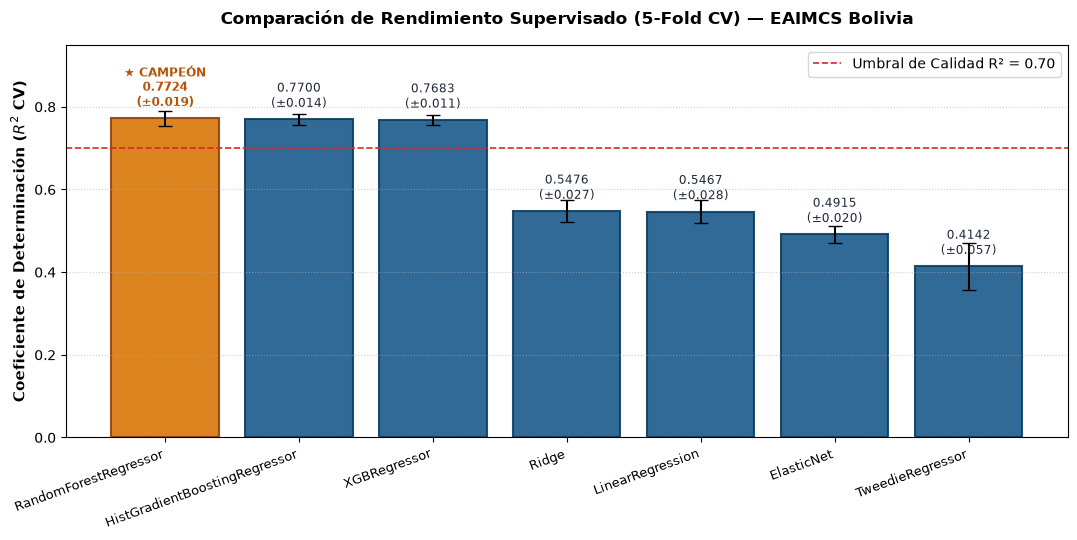

In [11]:
# Gráfico comparativo de barras mostrando R² con el modelo campeón resaltado
plt.figure(figsize=(11, 5.5), dpi=100)

model_names = df_comparativa["Modelo"].tolist()
r2_means = df_comparativa["R²_promedio"].tolist()
r2_stds = df_comparativa["R²_std"].tolist()

# Paleta de colores: Dorado/ámbar para el Campeón, azul institucional para el resto
bar_colors = ["#D97706" if "RandomForest" in name else "#1B5A8C" for name in model_names]
edge_colors = ["#92400E" if "RandomForest" in name else "#0B3D62" for name in model_names]

bars = plt.bar(
    model_names,
    r2_means,
    yerr=r2_stds,
    capsize=5,
    color=bar_colors,
    edgecolor=edge_colors,
    linewidth=1.5,
    alpha=0.9
)

# Anotación del valor R² y badge en cada barra
for bar, mean_val, std_val, name in zip(bars, r2_means, r2_stds, model_names):
    height = bar.get_height()
    if "RandomForest" in name:
        label = f"★ CAMPEÓN\n{mean_val:.4f}\n(±{std_val:.3f})"
        color_label = "#B45309"
        weight = "bold"
    else:
        label = f"{mean_val:.4f}\n(±{std_val:.3f})"
        color_label = "#1E293B"
        weight = "normal"
    plt.annotate(
        label,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight=weight,
        color=color_label
    )

plt.axhline(0.70, color="#DC2626", linestyle="--", linewidth=1.2, label="Umbral de Calidad R² = 0.70")
plt.ylim(0, 0.95)
plt.ylabel("Coeficiente de Determinación ($R^2$ CV)", fontsize=11, fontweight="bold")
plt.title("Comparación de Rendimiento Supervisado (5-Fold CV) — EAIMCS Bolivia", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=20, ha="right", fontsize=9.5)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

## 5. Exportación y Actualización de la Bitácora (`models/bitacora_modelos.json`)
Actualiza las entradas existentes y anexa los nuevos modelos evaluados manteniendo el esquema completo del proyecto.

In [12]:
# Exportación y actualización de models/bitacora_modelos.json
bitacora_path = PROJECT_ROOT / "models" / "bitacora_modelos.json"
artifacts_bitacora_path = PROJECT_ROOT / "dashboard" / "artifacts" / "bitacora_modelos.json"

version_id = f"v1.{datetime.now().strftime('%Y%m%d.%H%M')}"
timestamp_now = datetime.now().isoformat()

# Cargar bitácora previa si existe para preservar el historial
bitacora_data = {
    "ultima_actualizacion": timestamp_now,
    "iteracion_activa": version_id,
    "modelo_campeon": "RandomForest",
    "cobertura_ic_90_campeon": acumulador_modelos["RandomForestRegressor"]["test_metricas"]["cobertura_ic_90"],
    "modelos": [],
    "historial_iteraciones": []
}

if bitacora_path.exists():
    try:
        with open(bitacora_path, "r", encoding="utf-8") as f:
            prev_data = json.load(f)
            bitacora_data["historial_iteraciones"] = prev_data.get("historial_iteraciones", [])
            if prev_data.get("modelos"):
                bitacora_data["historial_iteraciones"].insert(0, {
                    "iteracion": prev_data.get("iteracion_activa", "anterior"),
                    "timestamp": prev_data.get("ultima_actualizacion", timestamp_now),
                    "modelos": prev_data.get("modelos", [])
                })
                bitacora_data["historial_iteraciones"] = bitacora_data["historial_iteraciones"][:10]
    except Exception as e:
        print(f"Aviso al cargar bitácora previa: {e}")

# Formatear entradas de los 7 modelos
modelos_export = []
for nombre, m in acumulador_modelos.items():
    entry = {
        "modelo": m["modelo"],
        "tipo": m["tipo"],
        "fecha": timestamp_now,
        "iteracion": version_id,
        "hiperparametros": m["hiperparametros"],
        "pliegues_cv": m["pliegues_cv"],
        "cv_resumen": {
            "r2_promedio": m["R²_promedio"],
            "r2_std": m["R²_std"],
            "rmse_promedio": m["RMSE_promedio"],
            "rmse_std": m["RMSE_std"],
            "mae_promedio": m["MAE_promedio"],
            "mae_std": m["MAE_std"],
            "medape_promedio": m["MedAPE_promedio"],
            "medape_std": m["MedAPE_std"]
        },
        "test_metricas": m["test_metricas"],
        "campeon": m["campeon"],
        "estado": m["estado"],
        "razon_decision": m["razon_decision"]
    }
    modelos_export.append(entry)

bitacora_data["ultima_actualizacion"] = timestamp_now
bitacora_data["iteracion_activa"] = version_id
bitacora_data["modelos"] = modelos_export

# Guardar en models/bitacora_modelos.json
bitacora_path.parent.mkdir(parents=True, exist_ok=True)
with open(bitacora_path, "w", encoding="utf-8") as f:
    json.dump(bitacora_data, f, indent=2, ensure_ascii=False)
print(f"✓ Bitácora oficial actualizada: {bitacora_path} ({len(modelos_export)} modelos registrados)")

# Sincronizar en dashboard/artifacts/
if artifacts_bitacora_path.parent.exists():
    with open(artifacts_bitacora_path, "w", encoding="utf-8") as f:
        json.dump(bitacora_data, f, indent=2, ensure_ascii=False)
    print(f"✓ Sincronizado en dashboard/artifacts/: {artifacts_bitacora_path}")

✓ Bitácora oficial actualizada: C:\Users\RAQUEL SERRANO\OneDrive\Documentos\ProyectoFinalML\finalProjectML\models\bitacora_modelos.json (7 modelos registrados)
✓ Sincronizado en dashboard/artifacts/: C:\Users\RAQUEL SERRANO\OneDrive\Documentos\ProyectoFinalML\finalProjectML\dashboard\artifacts\bitacora_modelos.json